In [61]:
import numpy as np
import matplotlib.pyplot as plt
import thermodynamics as thermo
import ODESolve_slow as ODE

In [63]:
def sth(T):
    sth=((2*np.pi**2*2*T**3)/45)+thermo.s(T,0.511,2)+thermo.s(T,0.511,2)
    return sth
print (sth(10))

2412.1348418210628


In [65]:
def dsthdT(T):
    dsthdT=(6*np.pi**2*2*T**2)/45+thermo.dsdT(T,0.511,2)+thermo.dsdT(T,0.511,2)
    return dsthdT

In [67]:
def ptot(T,a):
    ptot=(np.pi**2*2*T**4)/30+thermo.p(T,0.511,2)+thermo.p(T,0.511,2)+thermo.p(1/a,0,6)
    return ptot

In [69]:
def f(a,y,p):
   
    T,t=y
    der = np.zeros(2)
   
    der[0] = -(3*a**2*sth(T))/(a**3*dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ptot(T,a))/(3*(1.22*10**28)**2))**(1/2)

    
    return der

a0=0.1
y0=np.array([10,0])
dx0=0.001
p=None

N_step = 1000
dN = 2
x_final = 100

print(f(a0,y0,p)) 
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

[-9.99879777e+01  4.46148637e-25]
True


[ 10.           9.52246502   8.43343249   7.12366468   5.67321585
   4.1168402    2.52696846   1.04383704  -0.28950196  -1.43447498
  -2.72552881  -4.16270052  -5.70864247  -7.34233415  -9.05012595
 -10.82236559 -12.651829   -14.5328855  -16.46101021 -18.43247932
 -20.44416903 -22.49341752 -24.57792668 -26.69569027 -28.84494006
 -31.02410462 -33.23177721 -35.46669047 -37.72769601 -40.01374799
 -42.32388945 -44.65724121 -47.01299232 -49.39039232 -51.78874445
 -54.20739985 -56.64575271 -59.06450301]


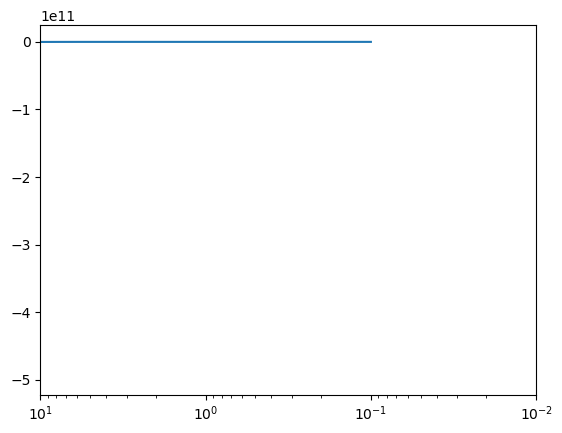

In [88]:
plt.figure()
T=y[:,0]
z=np.zeros(len(T))
for i in range(len(T)):
    z[i]=sth(T[i])*a[i]**3
plt.semilogx(a,z)
plt.xlim(10,0.01)
print(T)
   


(0.0, 20.0)

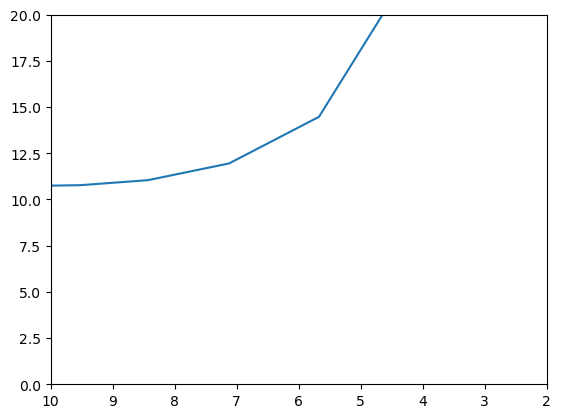

In [82]:
plt.figure()
T=y[:,0]
g=np.zeros(len(T))
for i in range(len(T)):
    g[i]=ptot(T[i],a[i])/(np.pi**2*T[i]**4/30)
plt.plot(T,g)
plt.xlim(10,2)
plt.ylim(0,20)
